In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

titanic_df = pd.read_csv("train.csv")

print("Original shape:", titanic_df.shape)
display(titanic_df.head(5))

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

🌟 **Exercise 1: Duplicate Detection and Removal**

In [4]:
#Check the number of rows before removing duplicates
rows_before = len(titanic_df)       

print("Rows before removing duplicates:", rows_before)

Rows before removing duplicates: 891


In [5]:
# Identify duplicate rows 

duplicates = titanic_df[titanic_df.duplicated()]

print(f"Number of duplicate rows: \n{duplicates.sum()}")

Number of duplicate rows: 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            0.0
SibSp            0
Parch            0
Ticket           0
Fare           0.0
Cabin            0
Embarked         0
dtype: object


In [6]:
#Remove  the duplicates
titanic_no_dup = titanic_df.drop_duplicates()


In [7]:
#Verify the removal
rows_after = len(titanic_no_dup)

print("Rows after removing duplicates:", rows_after)


Rows after removing duplicates: 891


In [8]:
# Verify that duplicates have been removed

print("Duplicates remaining:", titanic_no_dup.duplicated().sum())

Duplicates remaining: 0


**🌟 Exercise 2: Handling Missing Values**

In [9]:
#Identifying and counting missing values in each column
missing_values = titanic_no_dup.isnull().sum()

missing_values[missing_values > 0]


Age         177
Cabin       687
Embarked      2
dtype: int64

In [10]:
# Remove rows where the embarkation port is missing.
titanic_df = titanic_df.dropna(subset=["Embarked"]).copy()


In [13]:
# Calculate the median of the available ages.
median_age = titanic_df["Age"].median()

In [14]:
# Replace missing ages with that median.
titanic_df["Age"] = titanic_df["Age"].fillna(median_age)

In [15]:
# Replace missing cabin values with a descriptive constant.
titanic_df["Cabin"] = titanic_df["Cabin"].fillna("Unknown")

In [16]:
# Report how many rows were removed.
print("Rows removed:", rows_before - len(titanic_df))


Rows removed: 2


In [17]:
#  Check for any remaining missing values.
print("Missing values after cleaning:")
print(titanic_df.isna().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


**🌟 Exercise 3: Feature Engineering**

In [18]:
# Include the passenger when calculating family size.
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1

titanic_df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [19]:
# Extract the text between the comma and the following period.
titanic_df["Title"] = titanic_df["Name"].str.extract(r",\s*([^.]*)\.", expand=False)

titanic_df["Title"] = titanic_df["Title"].str.strip()

titanic_df["Title"] = titanic_df["Title"].fillna("Unknown")

titanic_df[["Name", "Title"]].head()

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


In [ ]:
titanic_df["Title"].value_counts()

In [ ]:
# Create one numerical indicator column for each title.
titanic_df = pd.get_dummies(titanic_df, columns=["Title"], prefix="Title", dtype=int)

titanic_df.filter(like="Title_").head()

In [ ]:
title_columns = titanic_df.filter(like="Title_").columns.tolist()

titanic_df[["FamilySize"] + title_columns].head()

***🌟 Exercise 4: Outlier Detection and Handling***

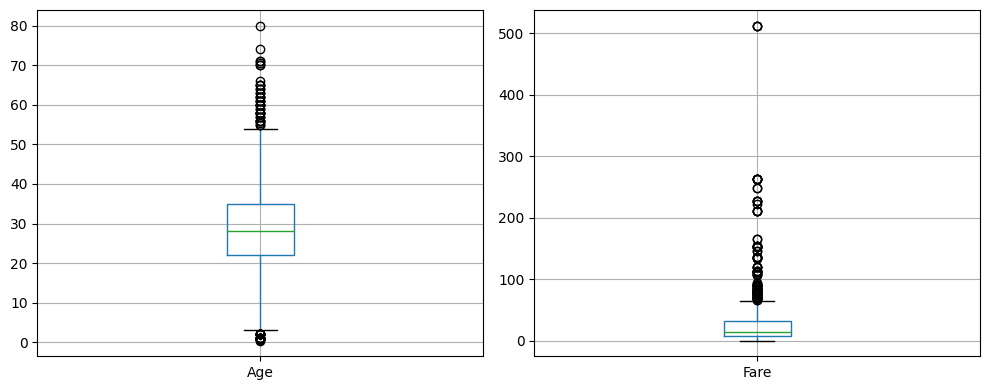

In [23]:
#Visualize potential outliers

before_outliers = titanic_df[["Age", "Fare"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

before_outliers.boxplot(column="Age", ax=axes[0])
before_outliers.boxplot(column="Fare", ax=axes[1])

plt.tight_layout()
plt.show()

In [24]:
#Detect outliers using the IQR method

q1 = before_outliers.quantile(0.25)
q3 = before_outliers.quantile(0.75)

iqr = q3 - q1

lower_bounds = q1 - 1.5 * iqr
upper_bounds = q3 + 1.5 * iqr

outlier_mask = (before_outliers < lower_bounds) | (before_outliers > upper_bounds)

print(outlier_mask.sum())

Age      65
Fare    114
dtype: int64


In [ ]:
#Compare possible thresholds for capping Fare

fare_quantiles = before_outliers["Fare"].quantile([0.95, 0.98, 0.99])

print(fare_quantiles)

In [ ]:
#Cap the highest roughly 2% of fares while keeping all passenger records

fare_cap = fare_quantiles.loc[0.98]
fare_capped = before_outliers["Fare"].clip(upper=fare_cap)

print("Fare cap:", fare_cap)
print("Fares above the cap:", (before_outliers["Fare"] > fare_cap).sum())

In [ ]:
#Explore log transformation to reduce the influence of large fares
#log1p also handles fares equal to zero

fare_log = np.log1p(before_outliers["Fare"])

fare_log.head()

In [ ]:
#Explore row removal on a separate copy

fare_no_outliers = titanic_df.loc[~outlier_mask["Fare"]].copy()

print("Rows before removal:", len(titanic_df))
print("Rows after removal:", len(fare_no_outliers))

In [ ]:
#Compare the three methods with the original fares
#Log-transformed values use a different scale

fare_comparison = pd.DataFrame({
    "Original": before_outliers["Fare"].describe(),
    "Capped": fare_capped.describe(),
    "Log transformed": fare_log.describe(),
    "Rows removed": fare_no_outliers["Fare"].describe()
})

display(fare_comparison)

In [ ]:
#Use capped fares for the remaining exercises
#Keep unusual ages because they may be valid observations

titanic_df["Fare"] = fare_capped

In [ ]:
#Compare Fare before and after capping

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

before_outliers.boxplot(column="Fare", ax=axes[0])
axes[0].set_title("Fare before capping")

titanic_df.boxplot(column="Fare", ax=axes[1])
axes[1].set_title("Fare after capping")

plt.tight_layout()
plt.show()

**🌟 Exercise 5: Data Standardization and Normalization**

In [ ]:
#Standardize Age and preserve the original ages for Exercise 7

age_scaler = StandardScaler()

titanic_df["Age_standardized"] = age_scaler.fit_transform(titanic_df[["Age"]]).ravel()

titanic_df[["Age", "Age_standardized"]].head()

In [ ]:
#Normalize capped Fare to the range [0, 1]
#Scaling changes the range but does not remove skewness

fare_scaler = MinMaxScaler()

titanic_df["Fare_normalized"] = fare_scaler.fit_transform(titanic_df[["Fare"]]).ravel()

titanic_df[["Fare", "Fare_normalized"]].head()

In [ ]:
#Verify standardization and normalization

print("Age mean:", titanic_df["Age_standardized"].mean())
print("Age standard deviation:", titanic_df["Age_standardized"].std(ddof=0))

print("Fare minimum:", titanic_df["Fare_normalized"].min())
print("Fare maximum:", titanic_df["Fare_normalized"].max())

**🌟 Exercise 6: Feature Encoding**

In [ ]:
#Identify the remaining categorical columns

categorical_columns = titanic_df.select_dtypes(include=["object", "string", "category"]).columns

print(categorical_columns.tolist())

In [ ]:
#Encode Sex and Embarked without assigning an artificial order
#Title was already encoded in Exercise 3
#Pclass is already numeric and ordered, so no label encoding is needed

titanic_df = pd.get_dummies(titanic_df, columns=["Sex", "Embarked"], dtype=int)

encoded_columns = titanic_df.filter(regex=r"^(Sex_|Embarked_|Title_)").columns

titanic_df[encoded_columns].head()

In [ ]:
#Remove raw text identifiers from this basic feature set
#Name has already supplied Title; Ticket and Cabin could be engineered later

titanic_df = titanic_df.drop(columns=["Name", "Ticket", "Cabin"])

print("Remaining categorical columns:")
print(titanic_df.select_dtypes(include=["object", "string", "category"]).columns.tolist())

**🌟 Exercise 7: Data Transformation for Age Feature**

In [ ]:
#Create age groups using Age in years
#Intervals: [0, 12], (12, 18], (18, 60], and above 60

age_bins = [0, 12, 18, 60, float("inf")]
age_labels = ["Child", "Teen", "Adult", "Senior"]

titanic_df["AgeGroup"] = pd.cut(
    titanic_df["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True,
    right=True
)

titanic_df[["Age", "AgeGroup"]].head()

In [ ]:
#Check the age groups before encoding
#Previously missing ages are grouped using their imputed values

print(titanic_df["AgeGroup"].value_counts(sort=False))
print("Missing age groups:", titanic_df["AgeGroup"].isna().sum())

In [ ]:
#Create one numerical indicator column for each age group

titanic_df = pd.get_dummies(titanic_df, columns=["AgeGroup"], prefix="AgeGroup", dtype=int)

age_group_columns = ["AgeGroup_Child", "AgeGroup_Teen", "AgeGroup_Adult", "AgeGroup_Senior"]

titanic_df[["Age"] + age_group_columns].head()

In [ ]:
#Verify the final dataset

print("Final shape:", titanic_df.shape)
print("Missing values remaining:", titanic_df.isna().sum().sum())
print("Each passenger has one age group:", titanic_df[age_group_columns].sum(axis=1).eq(1).all())

display(titanic_df.head())